In [33]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import librosa
from pathlib import Path
from IPython.display import Audio

import pygaborstm as stm

print(f"PyGaborSTM version: {stm.__version__}")

PyGaborSTM version: 0.1.0


In [42]:
# %% Load audio file
filepath = Path('notebooks/assets/hello_world.wav')

audio, sr = librosa.load(filepath, sr=16000)

print(f"Loaded: {filepath.name}")
print(f"Audio shape: {audio.shape}, SR: {sr}")
print(f"Duration: {len(audio)/sr:.2f}s")

Audio(audio, rate=sr)

Loaded: hello_world.wav
Audio shape: (18391,), SR: 16000
Duration: 1.15s


In [35]:
# Compute auditory spectrogram
spec_model = stm.AuditorySpectrogram()
spectrogram = spec_model.compute(audio)

print("\n=== Spectrogram Stats ===")
print(f"Shape: {spectrogram.shape}")
print(f"Min: {spectrogram.data.min():.6f}")
print(f"Max: {spectrogram.data.max():.6f}")
print(f"Mean: {spectrogram.data.mean():.6f}")
print(f"Std: {spectrogram.data.std():.6f}")
print(f"Time range: {spectrogram.times[0]:.3f}s - {spectrogram.times[-1]:.3f}s")
print(f"Freq range: {spectrogram.freqs[0]:.1f}Hz - {spectrogram.freqs[-1]:.1f}Hz")

print("\nFirst 5x5 corner:")
print(spectrogram.data[:5, :5])


=== Spectrogram Stats ===
Shape: (128, 72)
Min: 0.000000
Max: 0.308241
Mean: 0.072003
Std: 0.053440
Time range: 0.000s - 1.136s
Freq range: 180.0Hz - 7091.4Hz

First 5x5 corner:
[[0.00544994 0.00483539 0.00483347 0.00471061 0.00498911]
 [0.0060048  0.00547346 0.0043135  0.004799   0.00470501]
 [0.00627262 0.00565766 0.00442521 0.00550162 0.00479215]
 [0.0061786  0.00546759 0.00510959 0.00642591 0.00488137]
 [0.00601484 0.0049898  0.00615278 0.00663121 0.00446707]]


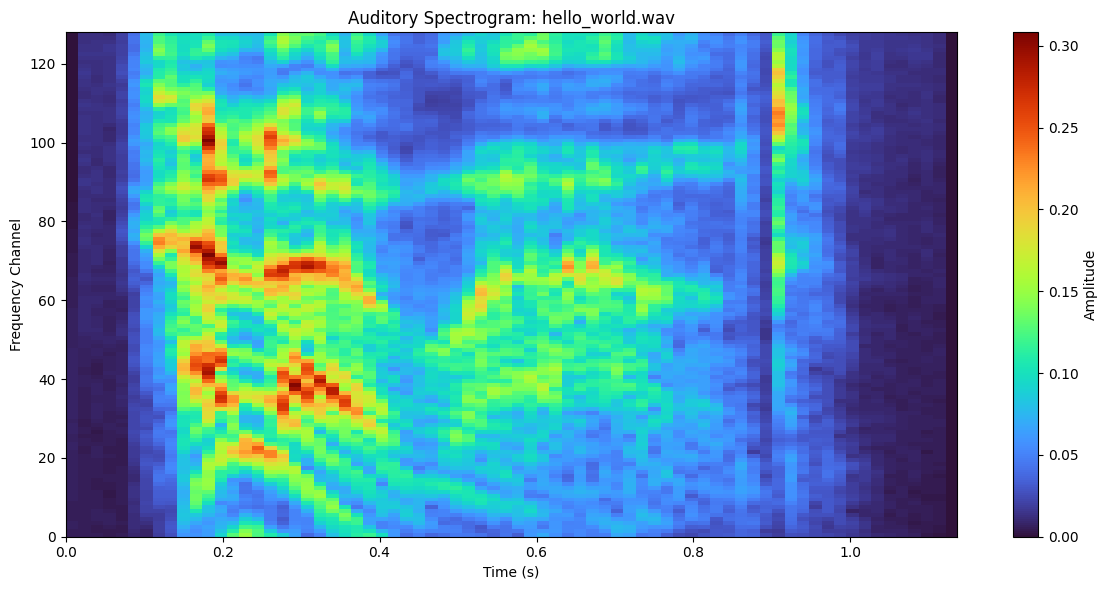

In [36]:
# Plot spectrogram
stm.plot_spectrogram(spectrogram, title=f"Auditory Spectrogram: {filename}")

In [37]:
# Compute RSF representation
gabor_model = stm.GaborFilterbank()
rsf = gabor_model.compute(spectrogram)

print("\n=== RSF Stats ===")
print(f"Shape: {rsf.shape}")
print(f"  - n_frames: {rsf.n_frames}")
print(f"  - n_rates: {rsf.n_rates}")
print(f"  - n_scales: {rsf.n_scales}")
print(f"  - n_freqs: {rsf.n_freqs}")
print(f"Min: {rsf.data.min():.6f}")
print(f"Max: {rsf.data.max():.6f}")
print(f"Rates: {rsf.rates}")
print(f"Scales: {rsf.scales}")


=== RSF Stats ===
Shape: (42, 10, 6, 128)
  - n_frames: 42
  - n_rates: 10
  - n_scales: 6
  - n_freqs: 128
Min: 0.042244
Max: 11.485378
Rates: [-32. -16.  -8.  -4.  -2.   2.   4.   8.  16.  32.]
Scales: [0.25 0.5  1.   2.   4.   8.  ]


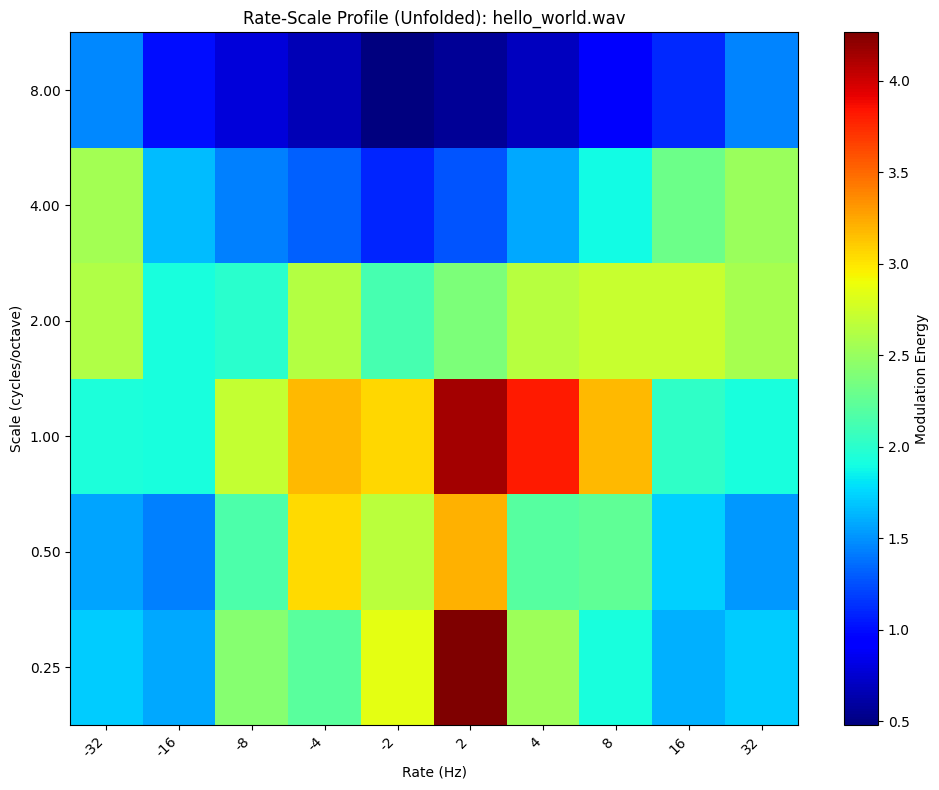

In [38]:
# Plot RSF - unfolded
stm.plot_rsf(rsf, title=f"Rate-Scale Profile (Unfolded): {filepath.name}")

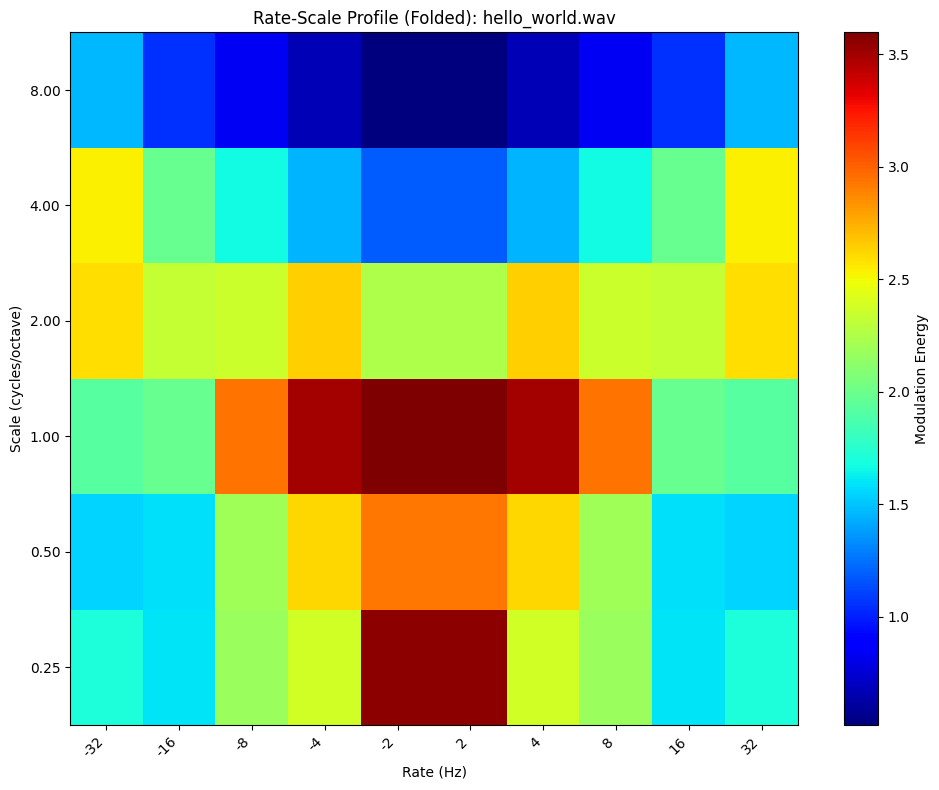

In [39]:
# Plot RSF - folded (symmetric)
stm.plot_rsf(rsf, fold=True, title=f"Rate-Scale Profile (Folded): {filepath.name}")


In [40]:
# Alternative: use the convenience function for the full pipeline
rsf_direct = stm.compute_rsf(audio, sr=sr)
print(f"Direct RSF shape: {rsf_direct.shape}")

Direct RSF shape: (42, 10, 6, 128)


In [41]:
# Access rate-scale matrix directly
rs_matrix = rsf.rate_scale_matrix(fold=False)
rs_folded = rsf.rate_scale_matrix(fold=True)
print(f"Rate-scale matrix shape: {rs_matrix.shape}")
print(f"Folded matrix shape: {rs_folded.shape}")

Rate-scale matrix shape: (6, 10)
Folded matrix shape: (6, 10)
